In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from scipy.special import rel_entr
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
import time

In [2]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input

In [3]:
def find_best_cnot_sequence_brute_force(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_vec_probs_target1: list or np.ndarray,
    state_vec_probs_target2: list or np.ndarray,
    max_cnot_depth: int = 1, # Limit the depth for practical reasons
    nshots: int = 1000
):
    """
    Performs a brute-force search to find the optimal sequence of CNOT gates
    between two quantum circuit "chunks" (circ1 and circ2) up to a specified depth.
    It evaluates all possible permutations of CNOTs and returns the sequence
    that yields the lowest combined KL divergence.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit (e.g., circ_bell).
        circ2 (QuantumCircuit): The second quantum circuit (e.g., circ_ghz_ish).
        state_vec_probs_target1 (list or np.array): The amplitudes of the target state vector
                                                     for the first classical register (c_measure1).
        state_vec_probs_target2 (list or np.array): The amplitudes of the target state vector
                                                     for the second classical register (c_measure2).
        max_cnot_depth (int): The maximum number of CNOT gates to include in a sequence.
                              Be cautious: computational cost grows exponentially with this value.
        nshots (int): The number of shots for the simulation. Defaults to 1000.

    Returns:
        tuple: A tuple containing (best_cnot_sequence, min_kl_sum).
               - best_cnot_sequence: A list of (global_control_idx, global_target_idx) tuples
                                     representing the optimal sequence of CNOTs found.
                                     An empty list if no CNOTs improve the baseline.
               - min_kl_sum: The minimum combined KL divergence found.
    """
    # Define a global tolerance for KL divergence stopping criteria
    KL_TOLERANCE = 0.00005

    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    print(f"\n--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: {num_total_qubits}, Max Depth: {max_cnot_depth}) ---")
    print(f"Number of qubits in chunk 1: {ng_circ1}")
    print(f"Number of qubits in chunk 2: {ng_circ2}")

    # 1. Evaluate baseline (no CNOTs)
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(
        base_combined_circuit, ng_circ1, []
    )
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(
        base_circuit_with_measurements,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    min_kl_sum = initial_kl_sum
    best_cnot_sequence = [] # List of (global_control, global_target) tuples

    print(f"\nBaseline (No CNOTs) KL Sum: {initial_kl_sum:.6f}")
    print(f"Initial best KL sum: {min_kl_sum:.6f} (from baseline)")

    # Generate all possible single CNOTs between the two chunks (global indices)
    all_possible_single_cnots = []
    for control_q1_idx in range(ng_circ1):
        for target_q2_idx in range(ng_circ2):
            # CNOT from chunk1 to chunk2
            all_possible_single_cnots.append((control_q1_idx, ng_circ1 + target_q2_idx))
            # CNOT from chunk2 to chunk1
            all_possible_single_cnots.append((ng_circ1 + target_q2_idx, control_q1_idx))

    # Brute-force search for the best sequence of CNOTs up to max_cnot_depth
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        print(f"\n--- Testing combinations with {num_cnots} CNOTs ---")
        # Use permutations to account for order, as CNOT order matters
        for cnot_combination in itertools.permutations(all_possible_single_cnots, num_cnots):
            temp_cnot_sequence = list(cnot_combination)

            # Create circuit with current CNOT sequence
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(
                temp_base_circuit, ng_circ1, temp_cnot_sequence
            )

            kl_div1, kl_div2 = score_circuit_kl_divergences(
                temp_circuit_with_cnots,
                state_vec_probs_target1,
                state_vec_probs_target2,
                nshots
            )

            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                # print(f"  Testing CNOT sequence {temp_cnot_sequence}: KL Sum {current_kl_sum:.6f}") # For debugging brute force

                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                
                # Check for early stopping criterion
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    search_complete_early = True
                    break # Exit inner loop

    end_time = time.time()
    print(f"Brute-Force CNOT search (max_depth={max_cnot_depth}) took: {end_time - start_time:.2f} seconds")
    
    # If no CNOT sequence improved over the baseline, return the baseline results
    if min_kl_sum >= initial_kl_sum:
        return [], initial_kl_sum
    else:
        return best_cnot_sequence, min_kl_sum



# ==============================================================================
# --- MAIN SEARCH ALGORITHMS (REFACTORED) ---
# ==============================================================================

def _run_single_greedy_search_from_start(
    circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
    all_possible_single_cnots, starting_cnot, min_cnot_depth, nshots,
):
    """
    [HELPER] Runs one greedy search path starting from a single CNOT.
    This version returns the best sequence found on this path, even if a later step is worse.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    best_cnot_sequence = [starting_cnot]
    
    initial_kl_for_path = score_circuit_kl_divergences(
        add_cnots_and_measurements_to_circuit(concatenate_circuits_with_separate_measurements(circ1, circ2), ng_circ1, best_cnot_sequence),
        state_vec_probs_target1, state_vec_probs_target2, nshots
    )
    if initial_kl_for_path is not None: initial_kl_for_path = initial_kl_for_path[0] + initial_kl_for_path[1]
    else: initial_kl_for_path = float('inf')

    best_sequence_on_path = list(best_cnot_sequence)
    best_kl_on_path = initial_kl_for_path
    current_kl_sum_on_path = initial_kl_for_path

    iteration_count = 1
    while True:
        iteration_count += 1
        improvement_made = False
        current_iteration_best_cnot = None
        current_iteration_min_kl_sum = current_kl_sum_on_path
        absolute_best_cnot_this_iter = None
        absolute_min_kl_sum_this_iter = float('inf')
        
        for candidate_cnot in all_possible_single_cnots:
            if candidate_cnot not in best_cnot_sequence:
                temp_cnot_sequence = best_cnot_sequence + [candidate_cnot]
                temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
                temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
                kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
                
                if kl_div1 is not None and kl_div2 is not None:
                    current_kl_sum = kl_div1 + kl_div2
                    
                    if current_kl_sum < current_iteration_min_kl_sum:
                        current_iteration_min_kl_sum = current_kl_sum
                        current_iteration_best_cnot = candidate_cnot
                        improvement_made = True
                    
                    if current_kl_sum < absolute_min_kl_sum_this_iter:
                        absolute_min_kl_sum_this_iter = current_kl_sum
                        absolute_best_cnot_this_iter = candidate_cnot
        
        if improvement_made:
            best_cnot_sequence.append(current_iteration_best_cnot)
            current_kl_sum_on_path = current_iteration_min_kl_sum
        else:
            if len(best_cnot_sequence) < min_cnot_depth and absolute_best_cnot_this_iter is not None:
                best_cnot_sequence.append(absolute_best_cnot_this_iter)
                current_kl_sum_on_path = absolute_min_kl_sum_this_iter
            else:
                break

        if current_kl_sum_on_path < best_kl_on_path:
            best_kl_on_path = current_kl_sum_on_path
            best_sequence_on_path = list(best_cnot_sequence)
            print(f"    --> Found a better KL on this path: {best_kl_on_path:.6f} at depth {len(best_sequence_on_path)}")

        if current_kl_sum_on_path < KL_TOLERANCE:
            print(f"  KL Sum ({current_kl_sum_on_path:.6f}) below tolerance. Early stopping this epoch.")
            break
            
    return best_sequence_on_path, best_kl_on_path

def _run_greedy_removal_search(
    circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
    initial_cnot_sequence, min_kl_sum_initial, min_cnot_depth, nshots
):
    """
    [NEW HELPER] Runs a greedy search by removing CNOTs from an initial sequence.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    best_cnot_sequence = list(initial_cnot_sequence)
    
    best_sequence_on_path = list(initial_cnot_sequence)
    best_kl_on_path = min_kl_sum_initial
    current_kl_sum_on_path = min_kl_sum_initial

    print(f"  Starting removal search with {len(initial_cnot_sequence)} CNOTs (KL Sum: {best_kl_on_path:.6f})")

    while len(best_cnot_sequence) > min_cnot_depth:
        improvement_made = False
        best_cnot_to_remove = None
        best_kl_after_removal = current_kl_sum_on_path
        
        for cnot_to_remove in best_cnot_sequence:
            temp_cnot_sequence = [c for c in best_cnot_sequence if c != cnot_to_remove]
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
            kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
            
            if kl_div1 is not None and kl_div2 is not None:
                current_kl_after_removal = kl_div1 + kl_div2
                if current_kl_after_removal < best_kl_after_removal:
                    best_kl_after_removal = current_kl_after_removal
                    best_cnot_to_remove = cnot_to_remove
                    improvement_made = True
        
        if improvement_made:
            best_cnot_sequence.remove(best_cnot_to_remove)
            current_kl_sum_on_path = best_kl_after_removal
            if current_kl_sum_on_path < best_kl_on_path:
                best_kl_on_path = current_kl_sum_on_path
                best_sequence_on_path = list(best_cnot_sequence)
                print(f"  Removed CNOT {best_cnot_to_remove}. New best KL Sum: {current_kl_sum_on_path:.6f} at depth {len(best_cnot_sequence)}")
        else:
            print("  No CNOT removal improved the score. Stopping removal search.")
            break
            
    return best_sequence_on_path, best_kl_on_path


def find_best_cnot_sequence_brute_force_on_list(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    cnot_list_to_test: list,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    max_cnot_depth: int,
    nshots: int
):
    """
    [NEW HELPER] Performs a brute-force search on a given list of CNOT candidates.
    """
    KL_TOLERANCE = 0.00005
    ng_circ1 = circ1.num_qubits
    
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(base_circuit_with_measurements, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')
    min_kl_sum = initial_kl_sum
    best_cnot_sequence = []
    
    print(f"\n--- Brute-force fallback: Testing permutations on {len(cnot_list_to_test)} candidates up to depth {max_cnot_depth} ---")
    start_time = time.time()
    for num_cnots in range(1, max_cnot_depth + 1):
        for cnot_combination in itertools.permutations(cnot_list_to_test, num_cnots):
            temp_cnot_sequence = list(cnot_combination)
            temp_base_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
            temp_circuit_with_cnots = add_cnots_and_measurements_to_circuit(temp_base_circuit, ng_circ1, temp_cnot_sequence)
            kl_div1, kl_div2 = score_circuit_kl_divergences(temp_circuit_with_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
            if kl_div1 is not None and kl_div2 is not None:
                current_kl_sum = kl_div1 + kl_div2
                if current_kl_sum < min_kl_sum:
                    min_kl_sum = current_kl_sum
                    best_cnot_sequence = temp_cnot_sequence
                    print(f"  --> New best sequence found: {best_cnot_sequence} with KL Sum: {min_kl_sum:.6f}")
                if min_kl_sum < KL_TOLERANCE:
                    print(f"  KL sum ({min_kl_sum:.6f}) below tolerance {KL_TOLERANCE}. Stopping early.")
                    return best_cnot_sequence, min_kl_sum
    
    end_time = time.time()
    print(f"Brute-Force CNOT search took: {end_time - start_time:.2f} seconds")
    
    if min_kl_sum >= initial_kl_sum: return [], initial_kl_sum
    else: return best_cnot_sequence, min_kl_sum

def find_best_cnot_sequence_multi_epoch(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    n_epochs: int = 10,
    min_cnot_depth: int = 1,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    [NEW MAIN] Performs a multi-epoch greedy search with a brute-force fallback.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits

    print(f"\n--- Starting Multi-Epoch Refined Search ---")
    start_total_time = time.time()
    
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    sv0 = Statevector(combined_state_amplitudes0)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv = Statevector(combined_state_amplitudes)
    density_matrix_sv0 = DensityMatrix(sv0)
    density_matrix_sv = DensityMatrix(sv)
    subtracted_density_matrix = density_matrix_sv - density_matrix_sv0
    matrix_to_plot = subtracted_density_matrix.data
    
    row_indices_sv, col_indices_sv = np.where(matrix_to_plot > threshold)
    row_indices_sv0, col_indices_sv0 = np.where(matrix_to_plot < -threshold)
    dim = matrix_to_plot.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    row_labels_sv = [labels[i] for i in row_indices_sv]
    col_labels_sv = [labels[i] for i in col_indices_sv]
    all_labels_set = set(row_labels_sv) | set(col_labels_sv)
    sorted_labels = sorted(all_labels_set)
    row_labels_sv0 = [labels[i] for i in row_indices_sv0]
    col_labels_sv0 = [labels[i] for i in col_indices_sv0]
    all_labels_set0 = set(row_labels_sv0) | set(col_labels_sv0)
    sorted_labels0 = sorted(all_labels_set0)
    num_total_qubits_for_config = len(sorted_labels[0]) if sorted_labels else 0
    # All possible configurations from states mapped
    all_cnot_configurations = set()
    for ibit_string in sorted_labels0:
        for jbit_string in sorted_labels:
            locations_i_qiskit = [num_total_qubits_for_config - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            locations_j_qiskit = [num_total_qubits_for_config - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            new_cnot_pairs = create_cnot_pairs_from_locations(locations_i_qiskit, locations_j_qiskit)
            all_cnot_configurations.update(new_cnot_pairs)
    all_possible_single_cnots = sorted(list(all_cnot_configurations))
    
    print(f"Number of original CNOT candidates: {ng_circ1 * ng_circ2 * 2}")
    print(f"Number of refined CNOT candidates: {len(all_possible_single_cnots)}")

    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_with_measurements = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_div1_no_cnot, kl_div2_no_cnot = score_circuit_kl_divergences(base_circuit_with_measurements, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_div1_no_cnot + kl_div2_no_cnot if kl_div1_no_cnot is not None and kl_div2_no_cnot is not None else float('inf')

    best_overall_sequence = []
    best_overall_kl_sum = initial_kl_sum
    
    if not all_possible_single_cnots:
        print("\nNo CNOT candidates found. Skipping all searches.")
    else:
        # --- Multi-Epoch greedy search (addition) ---
        num_epochs_to_run = min(n_epochs, len(all_possible_single_cnots))
        shuffled_candidates = all_possible_single_cnots.copy()
        random.shuffle(shuffled_candidates)
        
        for epoch in range(num_epochs_to_run):
            starting_cnot = shuffled_candidates[epoch]
            temp_kl_sum = score_circuit_kl_divergences(add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [starting_cnot]), 
                                                       state_vec_probs_target1, state_vec_probs_target2, nshots)


            if temp_kl_sum is not None: 
                temp_kl_sum = temp_kl_sum[0] + temp_kl_sum[1]
                print(f"\n--- Starting Epoch {epoch + 1}/{num_epochs_to_run} (Addition) with CNOT: {starting_cnot} (KL: {temp_kl_sum:.6f}) ---")
            else:
                print(f"\n--- Starting Epoch {epoch + 1}/{num_epochs_to_run} ---")
                continue
            

            if temp_kl_sum >= initial_kl_sum: continue
            
            best_sequence_this_epoch, min_kl_this_epoch = _run_single_greedy_search_from_start(
                circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
                all_possible_single_cnots, starting_cnot, min_cnot_depth, nshots
            )
            
            print(f"  Epoch {epoch + 1} best KL Sum: {min_kl_this_epoch:.6f}")
            if min_kl_this_epoch < best_overall_kl_sum:
                best_overall_kl_sum = min_kl_this_epoch
                best_overall_sequence = best_sequence_this_epoch
                print(f"  --> Epoch {epoch + 1} found a new overall best KL Sum: {best_overall_kl_sum:.6f}")
        
        # --- Greedy CNOT removal search ---
        if best_overall_sequence:
            print("\n--- Starting Greedy CNOT Removal Search ---")
            best_sequence_after_removal, best_kl_after_removal = _run_greedy_removal_search(
                circ1, circ2, state_vec_probs_target1, state_vec_probs_target2,
                best_overall_sequence, best_overall_kl_sum, 0, nshots
            )
            if best_kl_after_removal < best_overall_kl_sum:
                best_overall_kl_sum = best_kl_after_removal
                best_overall_sequence = best_sequence_after_removal
                print(f"\n--> Removal search found a new overall best KL Sum: {best_overall_kl_sum:.6f}")

    # --- Brute-Force Fallback ---
    if best_overall_kl_sum >= initial_kl_sum:
        print(f"\nGreedy search failed to improve baseline KL sum ({best_overall_kl_sum:.6f}).")
        print("Initiating brute-force fallback on all candidate permutations.")
        brute_force_max_depth = min(4, len(all_possible_single_cnots))
        best_overall_sequence_bf, best_overall_kl_sum_bf = find_best_cnot_sequence_brute_force_on_list(
            circ1, circ2, all_possible_single_cnots, state_vec_probs_target1, state_vec_probs_target2,
            max_cnot_depth=brute_force_max_depth, nshots=nshots
        )
        if best_overall_kl_sum_bf < best_overall_kl_sum:
            best_overall_sequence = best_overall_sequence_bf
            best_overall_kl_sum = best_overall_kl_sum_bf
            print(f"\n--> Brute-force fallback found a better sequence with KL Sum: {best_overall_kl_sum:.6f}")
    
    end_total_time = time.time()
    print(f"\nTotal search took: {end_total_time - start_total_time:.2f} seconds.")
    
    return best_overall_sequence, best_overall_kl_sum


In [4]:
# 1. Define initial circuits for concatenation Dictionaries
state_probs_bell = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)} # 2-qubit state
circ_bell = create_initial_circuit2(state_probs_bell)

state_probs_ghz_ish = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)} # 2-qubit state
circ_ghz_ish = create_initial_circuit2(state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)}
state_probs_target2_amplitudes = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)}


In [ ]:
# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 4 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 4) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.062415
Initial best KL sum: 40.062415 (from baseline)

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 29.997101
  --> New best sequence found: [(2, 0)] with KL Sum: 29.472471
  --> New best sequence found: [(0, 3)] with KL Sum: 29.232968
  --> New best sequence found: [(3, 0)] with KL Sum: 28.874429

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 18.745092
  --> New best sequence found: [(0, 2), (3, 1)] with KL Sum: 18.744063
  --> New best sequence found: [(2, 0), (0, 3)] with KL Sum: 18.165850
  --> New best sequence found: [(0, 3), (2, 1)] with KL Sum: 18.164309
  --> New best sequence found: [(3, 0), (1, 2)] with KL Sum: 18.006539
  --> New best sequence found: [(2

In [ ]:
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [ ]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [8]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 20
min_greedy_depth = 10

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ_bell,
    circ_ghz_ish,
    state_probs_bell,
    state_probs_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=1000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 8
Number of refined CNOT candidates: 12

--- Starting Epoch 1/12 (Addition) with CNOT: (2, 0) (KL: 29.232764) ---
    --> Found a better KL on this path: 18.144830 at depth 2
    --> Found a better KL on this path: 9.443572 at depth 3
    --> Found a better KL on this path: 9.083280 at depth 4
    --> Found a better KL on this path: 0.000234 at depth 5
  Epoch 1 best KL Sum: 0.000234
  --> Epoch 1 found a new overall best KL Sum: 0.000234

--- Starting Epoch 2/12 (Addition) with CNOT: (1, 3) (KL: 29.413467) ---
    --> Found a better KL on this path: 17.925581 at depth 2
    --> Found a better KL on this path: 9.025835 at depth 5
    --> Found a better KL on this path: 0.001701 at depth 6
    --> Found a better KL on this path: 0.000370 at depth 8
  Epoch 2 best KL Sum: 0.000370

--- Starting Epoch 3/12 (Addition) with CNOT: (1, 2) (KL: 29.174077) ---
    --> Fou

In [ ]:
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [ ]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [ ]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on Brute-Force CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    best_cnot_sequence_brute_force, # Use the CNOT topology found by brute-force
    nshots=2000,
    etol=1e-4,
    opt_method='L-BFGS-B', # Using L-BFGS-B for angle optimization
    initial_angle_value=np.pi # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish),
    circ_bell.num_qubits,
    best_cnot_sequence_brute_force,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [9]:
import numpy as np

# --- Function to normalize dictionary values ---
def vector_normalize_dictionary_values(input_dict):
    """Normalizes the values of a dictionary by dividing each value by the L2 norm of all values."""
    values = np.array(list(input_dict.values()), dtype=float)
    if values.size == 0:  # Handle empty dictionary
        return {}
    
    norm_val = np.linalg.norm(values)  # Calculate the L2 norm of the values

    if norm_val == 0:  # Avoid division by zero if all values are zero
        return {key: 0.0 for key in input_dict}

    normalized_dict = {}
    # Iterate through original dictionary items to maintain key order
    for i, (key, value) in enumerate(input_dict.items()):
        normalized_dict[key] = values[i] / norm_val
    return normalized_dict

In [10]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

def _single_cnot_insertion_search(
    base_circuit: QuantumCircuit,
    ng_circ1: int,
    current_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float
):
    """
    Finds the best single CNOT to insert into the current sequence at the best location.
    Returns the new sequence, its KL sum, and the added CNOT.
    """
    #print("   - Entering single CNOT insertion search -")
    best_single_cnot = None
    best_insertion_index = -1
    min_kl_after_add = float('inf')
    n_trials = 0
    
    remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
    if not remaining_cnots:
        print("   - No remaining CNOTs to add. Ending single-CNOT search.")
        return current_sequence, float('inf'), None

    for cnot_to_add in remaining_cnots:
        # Try inserting the CNOT at every possible position in the current sequence
        for i in range(len(current_sequence) + 1):
            n_trials += 1
            trial_sequence = current_sequence[:i] + [cnot_to_add] + current_sequence[i:]
            
            trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
            kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
            
            if kl_divs is not None:
                kl_sum = kl_divs[0] + kl_divs[1]
                if kl_sum < min_kl_after_add:
                    min_kl_after_add = kl_sum
                    best_single_cnot = cnot_to_add
                    best_insertion_index = i
                    
    
    if best_single_cnot is not None:
        new_sequence = current_sequence[:best_insertion_index] + [best_single_cnot] + current_sequence[best_insertion_index:]
        return new_sequence, min_kl_after_add, best_single_cnot
        print(f"  - No. CNOT tested insertion: {n_trials} | Best insertion KL sum: {min_kl_of_candidates:.6f}")
    else:
        print(f"  - No. CNOT tested insertion: {n_trials}")

    return current_sequence, float('inf'), None

def _pairwise_addition_search(
    base_circuit: 'QuantumCircuit',
    ng_circ1: int,
    initial_sequence: list,
    candidate_cnots: list,
    target_probs1: dict,
    target_probs2: dict,
    nshots: int,
    kl_tolerance: float = 0.00005
):
    """
    Iteratively adds the best CNOT pair or single CNOT based on which provides
    the greater reduction in KL divergence.
    Returns the final sequence and its corresponding KL sum.
    """
    print("  - Starting CNOT search -")
    current_sequence = list(initial_sequence)
    
    # Calculate baseline KL with the initial sequence
    base_circuit_kl = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, current_sequence)
    kl_divs_base = score_circuit_kl_divergences(base_circuit_kl, target_probs1, target_probs2, nshots)
    best_kl_sum = kl_divs_base[0] + kl_divs_base[1] if kl_divs_base is not None else float('inf')
    
    improvement_made = True
    min_kl_of_candidates = best_kl_sum
    while improvement_made:
        improvement_made = False
        
        # Initialize best candidates for this iteration
        best_candidate_sequence = None
        
        
        remaining_cnots = [c for c in candidate_cnots if c not in current_sequence]
        
        # --- PHASE 1: Find the best PAIR to add ---
        if len(remaining_cnots) >= 2:
            best_pair_to_add = None
            min_kl_after_pair_add = float('inf')
            n_trials_pair = 0

            for pair in itertools.permutations(remaining_cnots, 2):
                n_trials_pair += 1
                trial_sequence = current_sequence + list(pair)
                trial_circuit = add_cnots_and_measurements_to_circuit(base_circuit, ng_circ1, trial_sequence)
                kl_divs = score_circuit_kl_divergences(trial_circuit, target_probs1, target_probs2, nshots)
                
                if kl_divs is not None:
                    kl_sum = kl_divs[0] + kl_divs[1]
                    if kl_sum < min_kl_after_pair_add:
                        min_kl_after_pair_add = kl_sum
                        best_pair_to_add = list(pair)
            
            if best_pair_to_add is not None:
                min_kl_of_candidates = min_kl_after_pair_add
                best_candidate_sequence = current_sequence + best_pair_to_add
                print(f"  - No. tested pairs: {n_trials_pair} | Best pair KL sum: {min_kl_of_candidates:.6f}")
            else: 
                print(f"  - No. tested pairs: {n_trials_pair}")


        # --- PHASE 2: Find the best SINGLE CNOT to add ---
        new_sequence_single, new_kl_sum_single, added_cnot = _single_cnot_insertion_search(
            base_circuit, ng_circ1, current_sequence, candidate_cnots,
            target_probs1, target_probs2, nshots, kl_tolerance
        )
        
        if added_cnot is not None:
            if new_kl_sum_single < min_kl_of_candidates:
                min_kl_of_candidates = new_kl_sum_single
                best_candidate_sequence = new_sequence_single
                print(f"  - Best CNOT insertion KL Sum: {min_kl_of_candidates:.6f}")
            else:
                print("  - Single CNOT insertion did not improve upon the best pair.")


        # --- PHASE 3: Update the sequence if a better candidate was found ---
        if best_candidate_sequence is not None and min_kl_of_candidates < best_kl_sum - kl_tolerance:
            current_sequence = best_candidate_sequence
            best_kl_sum = min_kl_of_candidates
            improvement_made = True
            print(f"  - Adopted new sequence. New KL Sum: {best_kl_sum:.6f}")
        else:
            print("  - No significant improvement found from pairs or single CNOTs. Ending search.")
            break
                
    return current_sequence, best_kl_sum

def find_best_cnot_sequence_iterative_pairwise2(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05
):
    """
    Performs an iterative optimization loop by separating pairwise addition
    and removal phases.
    """
    import time
    
    ng_circ1 = circ1.num_qubits
    KL_TOLERANCE = 0.00005

    print(f"\n--- Starting Iterative Pairwise Search ---")
    start_total_time = time.time()

    # --- Step 1: Build refined CNOT candidate list ---
    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)
    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    initial_cnot_config = sorted(list(all_cnot_configurations))

    print(f"Number of initial CNOT candidates: {len(initial_cnot_config)}")
    
    # Optional: Plotting Real and Imaginary parts separately (also without annotations)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(np.real(matrix_data),
                annot=False,
                cmap="RdBu",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[0])
    axes[0].set_title("Real Part of Subtracted Density Matrix")
    axes[0].set_xlabel("Column Index (Binary State)")
    axes[0].set_ylabel("Row Index (Binary State)")

    sns.heatmap(np.imag(matrix_data),
                annot=False,
                cmap="coolwarm",
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                ax=axes[1])
    axes[1].set_title("Imaginary Part of Subtracted Density Matrix")
    axes[1].set_xlabel("Column Index (Binary State)")
    axes[1].set_ylabel("Row Index (Binary State)")

    plt.tight_layout()
    plt.savefig('dens_state_diff.svg')
    
    # --- Step 2: Baseline (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs = score_circuit_kl_divergences(base_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs[0] + kl_divs[1] if kl_divs is not None else float('inf')

    print(f"Initial KL-divergence: {initial_kl_sum:.6f}")

    if len(initial_cnot_config) < 2:
        print("Not enough CNOT candidates to form a pair. Skipping search.")
        return initial_cnot_config, [], [], initial_kl_sum

    # --- Step 3: Pairwise Addition Phase ---
    best_add_sequence, best_add_kl_sum = _pairwise_addition_search(
        base_combined_circuit, ng_circ1, [], initial_cnot_config,
        state_vec_probs_target1, state_vec_probs_target2, nshots, KL_TOLERANCE
    )
    print(f"\n--- Pairwise Addition Result ---")
    print(f"Best sequence after addition: {best_add_sequence}")
    print(f"KL sum after addition: {best_add_kl_sum:.6f}")

    end_time = time.time()
    print(f"\nTotal search time: {end_time - start_total_time:.2f} seconds.")

    # Return the configurations as requested
    return (
        initial_cnot_config,
        best_add_sequence,
        best_add_kl_sum
    )


--- Running iterative pair-wise Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 12
Initial KL-divergence: 40.063391
  - Starting CNOT search -
  - No. tested pairs: 132 | Best pair KL sum: 9.797422
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 9.797422
  - No. tested pairs: 90 | Best pair KL sum: 8.626230
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 8.626230
  - No. tested pairs: 56 | Best pair KL sum: 8.822494
  - Best CNOT insertion KL Sum: 8.743617
  - No significant improvement found from pairs or single CNOTs. Ending search.

--- Pairwise Addition Result ---
Best sequence after addition: [(2, 3), (3, 1), (0, 3), (0, 2)]
KL sum after addition: 8.626230

Total search time: 50.31 seconds.

Iterative Search Optimal CNOT sequence found after addition phase:
  q[2] -> q[3]
  q[3] -> q[1]
  q[0] -> q[3]
  q[0] -> q[2]
With minimum combine

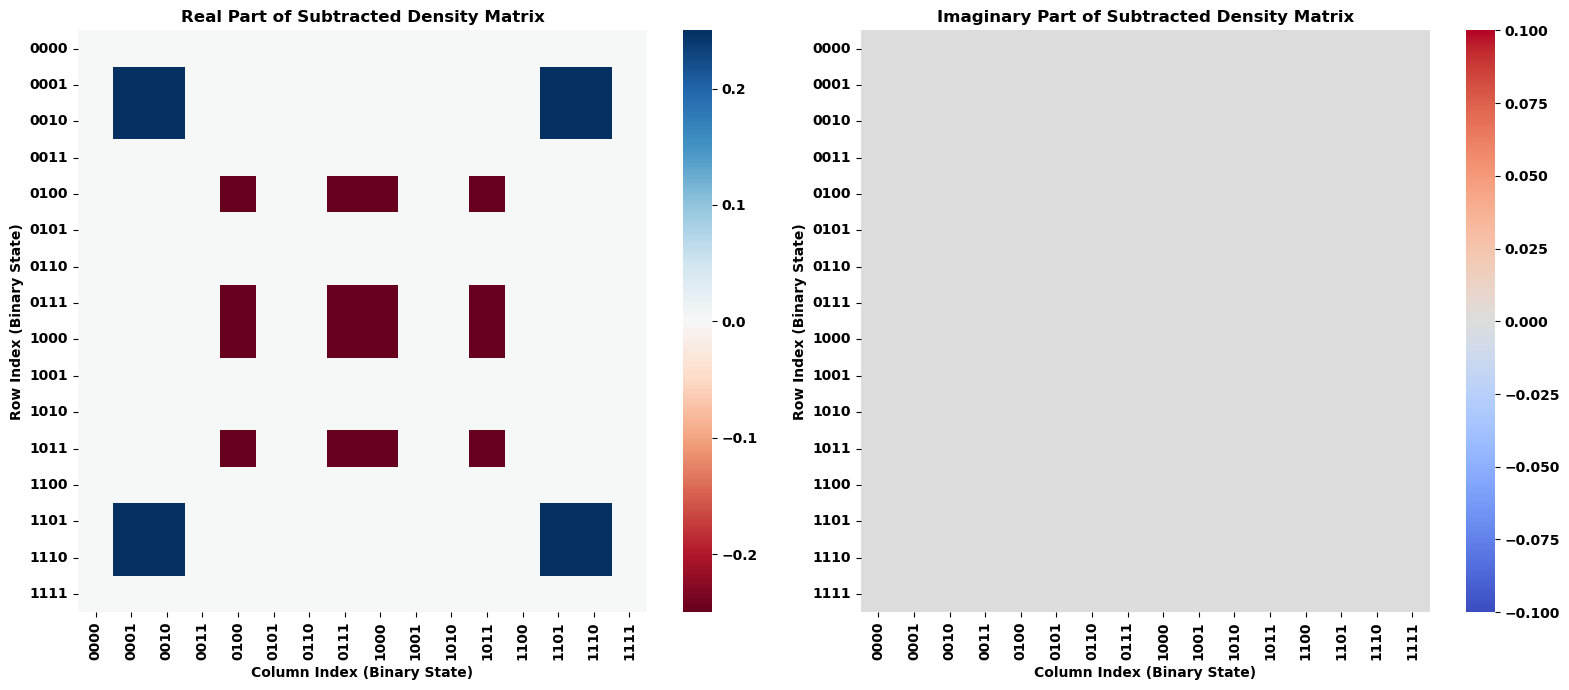

In [12]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# This is the call:
# --- Demonstrate Iterative Pairwise Search ---
print("\n" + "="*40)
print("--- Running iterative pair-wise Search ---")
print("="*40)

# Apply vector normalization to the new dictionaries
normalized_state_target1_amplitudes = vector_normalize_dictionary_values(state_probs_target1_amplitudes)
normalized_state_target2_amplitudes = vector_normalize_dictionary_values(state_probs_target2_amplitudes)
normalized_state_bell = vector_normalize_dictionary_values(state_probs_bell)
normalized_state_ghz_ish = vector_normalize_dictionary_values(state_probs_ghz_ish)


initial_cnot_config, best_add_sequence, best_add_kl_sum = find_best_cnot_sequence_iterative_pairwise2(
    circ_bell,
    circ_ghz_ish,
    normalized_state_bell, 
    normalized_state_ghz_ish,
    normalized_state_target1_amplitudes,
    normalized_state_target2_amplitudes,
    nshots=1000,
    threshold=0.02
)

print("\n" + "="*40)
if best_add_sequence: # Use best_add_sequence as it's the result of the addition phase
    print("Iterative Search Optimal CNOT sequence found after addition phase:")
    for cnot in best_add_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {best_add_kl_sum:.6f}")

    # Construct and draw the final best circuit from the search
    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_add_sequence
    )
    print("\n--- Final Optimized Circuit (Iterative Pairwise Search) ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Iterative Pairwise Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {best_add_kl_sum:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


In [ ]:
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [ ]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [13]:
# --- New Dictionary Definitions ---
# State Set 5a: A simple distribution where states with more '1's have higher values.
state_set_5a_dict = {
    '000': 1,
    '001': 2,
    '010': 2,
    '100': 2,
    '011': 4,
    '101': 4,
    '110': 4,
    '111': 8
}

# State Set 6a: A bell state-like distribution where certain states are highly probable.
# This simulates an entangled state before interaction.
state_set_6a_dict = {
    '0000': 5,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 5
}

# Interacted State Set 5a: Simulating a CNOT interaction between qubits 1 and 2
# We increase the probability of entangled states like '011' and '110'.
interacted_state_set_5a_dict = {
    '000': 1,
    '001': 1,
    '010': 1,
    '100': 1,
    '011': 6,
    '101': 2,
    '110': 6,
    '111': 2
}

# Interacted State Set 6a: The bell state distribution is now more focused on states
# that would result from an interaction, such as '0000' and '1111' becoming highly probable.
interacted_state_set_6a_dict = {
    '0000': 8,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 8
}

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set 5a:", state_set_5a_dict)
print("State Set 6a:", state_set_6a_dict)
print("Interacted State Set 5a:", interacted_state_set_5a_dict)
print("Interacted State Set 6a:", interacted_state_set_6a_dict)

# Apply vector normalization to the new dictionaries
normalized_state_set_5a_dict_vec = vector_normalize_dictionary_values(state_set_5a_dict)
normalized_state_set_6a_dict_vec = vector_normalize_dictionary_values(state_set_6a_dict)
normalized_interacted_state_set_5a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_5a_dict)
normalized_interacted_state_set_6a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_6a_dict)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_state_set_5a_dict_vec)
print("Normalized State Set 6a (Vector Norm):", normalized_state_set_6a_dict_vec)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_interacted_state_set_5a_dict_vec)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_interacted_state_set_6a_dict_vec)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_state_set_5a_dict_vec)
circ2 = create_initial_circuit2(normalized_state_set_6a_dict_vec)

--- New Dictionary Definitions ---
State Set 5a: {'000': 1, '001': 2, '010': 2, '100': 2, '011': 4, '101': 4, '110': 4, '111': 8}
State Set 6a: {'0000': 5, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 5}
Interacted State Set 5a: {'000': 1, '001': 1, '010': 1, '100': 1, '011': 6, '101': 2, '110': 6, '111': 2}
Interacted State Set 6a: {'0000': 8, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 8}

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'000': 0.08944271909999159, '001': 0.17888543819998318, '010': 0.17888543819998318, '100': 0.17888543819998318, '011': 0.35777087639996635, '101': 0.35777087639996635, '110': 0.35777087639996635, '111': 0.7155417527999327}
Normalized State Set 6a (Vector Norm): {'0000': 0.625, '00


--- Running Multi-Epoch Refined Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 42
Initial KL-divergence: 1.169789
  - Starting CNOT search -
  - No. tested pairs: 1722 | Best pair KL sum: 0.344637
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.344637
  - No. tested pairs: 1560 | Best pair KL sum: 0.342742
  - Best CNOT insertion KL Sum: 0.334106
  - Adopted new sequence. New KL Sum: 0.334106
  - No. tested pairs: 1482 | Best pair KL sum: 0.313483
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.313483
  - No. tested pairs: 1332 | Best pair KL sum: 0.322068
  - Single CNOT insertion did not improve upon the best pair.
  - No significant improvement found from pairs or single CNOTs. Ending search.

--- Pairwise Addition Result ---
Best sequence after addition: [(3, 2), (1, 2), (2, 0), (2, 1), (3, 1)]
KL sum after addition: 0.313483

Total

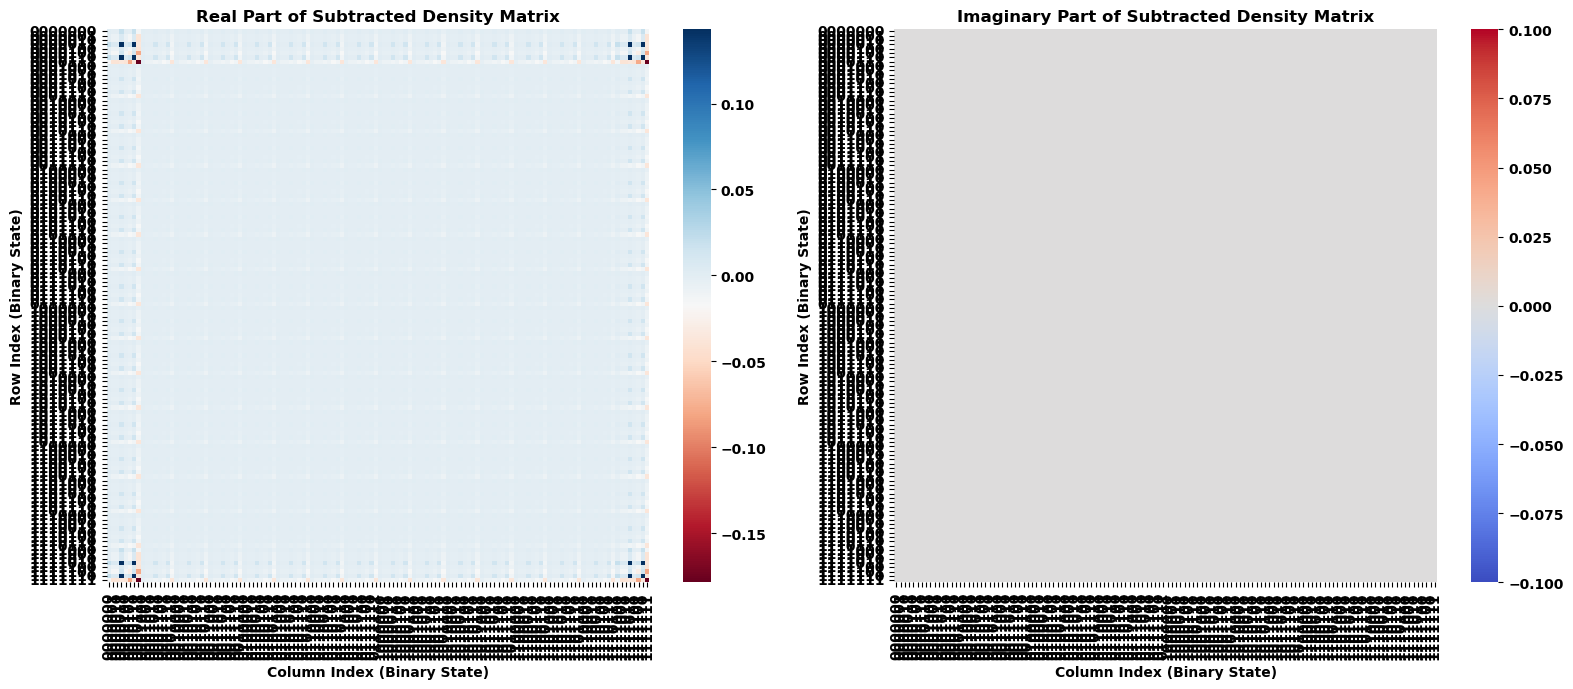

In [14]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

initial_cnot_config, best_cnot_sequence, min_kl_sum  = find_best_cnot_sequence_iterative_pairwise2(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    nshots=2000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")

In [ ]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=2000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [15]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 20

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=1000,
    threshold=0.05
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 24
Number of refined CNOT candidates: 42

--- Starting Epoch 1/42 (Addition) with CNOT: (6, 3) (KL: 2.809353) ---

--- Starting Epoch 2/42 (Addition) with CNOT: (1, 6) (KL: 3.304601) ---

--- Starting Epoch 3/42 (Addition) with CNOT: (3, 1) (KL: 1.323223) ---

--- Starting Epoch 4/42 (Addition) with CNOT: (4, 3) (KL: 2.706667) ---

--- Starting Epoch 5/42 (Addition) with CNOT: (3, 6) (KL: 2.783218) ---

--- Starting Epoch 6/42 (Addition) with CNOT: (6, 0) (KL: 0.837638) ---
    --> Found a better KL on this path: 0.388472 at depth 2
  Epoch 6 best KL Sum: 0.388472
  --> Epoch 6 found a new overall best KL Sum: 0.388472

--- Starting Epoch 7/42 (Addition) with CNOT: (3, 5) (KL: 2.800830) ---

--- Starting Epoch 8/42 (Addition) with CNOT: (4, 2) (KL: 0.888426) ---
    --> Found a better KL on this path: 0.368361 at depth 2
  Epoch 8 best KL Sum: 0.368361
  --> Epoc

In [26]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("dataset_co_mo2.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [27]:
gl_source = ['STAT3','IL6RorST','TGFBR1or2','PDGFB'] # All values from the first column
gl_recv =['PDGFRB', 'TGFB1', 'IL6']  # All values from the second column

In [28]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

Xct1_co = adata_ct1_co.X.toarray()
Xct2_co = adata_ct2_co.X.toarray()
#Xct1_co = adata_ct1_co.X
#Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [29]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

# Library size normalization 
Xct1_mo = adata_ct1_mo.X.toarray()
Xct2_mo = adata_ct2_mo.X.toarray()
#Xct1_mo = adata_ct1_mo.X
#Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'


In [30]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

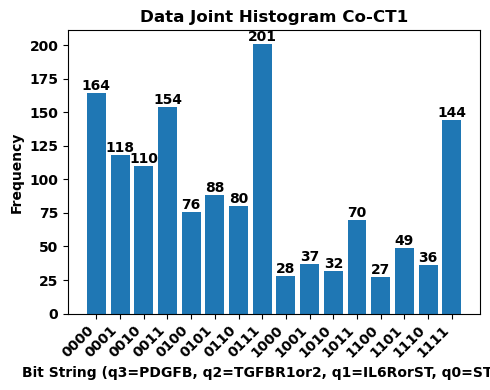

Joint Counts: Counter({'0111': 201, '0000': 164, '0011': 154, '1111': 144, '0001': 118, '0010': 110, '0101': 88, '0110': 80, '0100': 76, '1011': 70, '1101': 49, '1001': 37, '1110': 36, '1010': 32, '1000': 28, '1100': 27})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [31]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

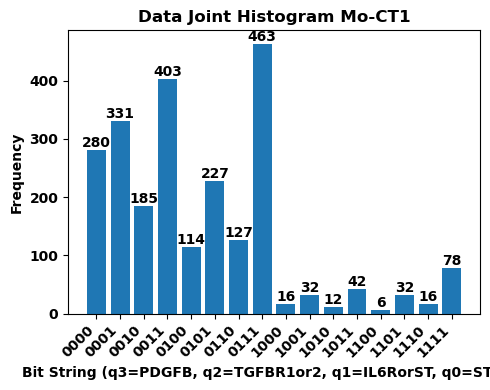

Joint Counts: Counter({'0111': 463, '0011': 403, '0001': 331, '0000': 280, '0101': 227, '0010': 185, '0110': 127, '0100': 114, '1111': 78, '1011': 42, '1101': 32, '1001': 32, '1110': 16, '1000': 16, '1010': 12, '1100': 6})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [32]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

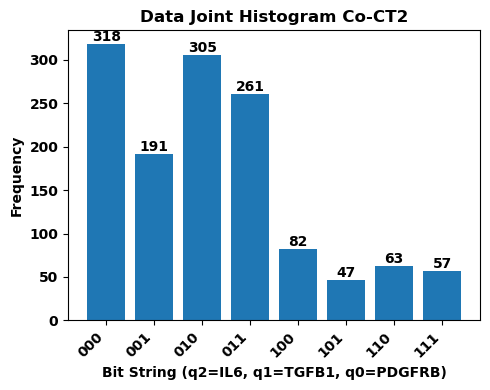

Joint Counts: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [33]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

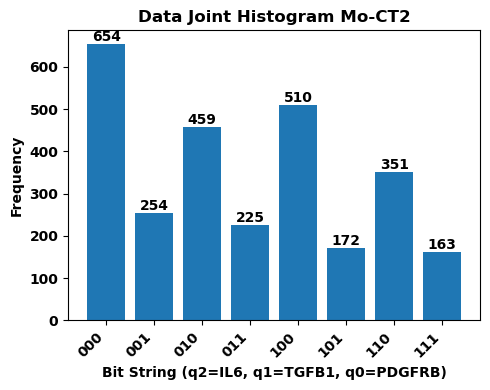

Joint Counts: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [34]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [35]:
import numpy as np
# --- Function to normalize dictionary values ---
def vector_normalize_dictionary_values(input_dict):
    """Normalizes the values of a dictionary by dividing each value by the L2 norm of all values."""
    values = np.array(list(input_dict.values()), dtype=float)
    if values.size == 0:  # Handle empty dictionary
        return {}
    
    norm_val = np.linalg.norm(values)  # Calculate the L2 norm of the values

    if norm_val == 0:  # Avoid division by zero if all values are zero
        return {key: 0.0 for key in input_dict}

    normalized_dict = {}
    # Iterate through original dictionary items to maintain key order
    for i, (key, value) in enumerate(input_dict.items()):
        normalized_dict[key] = values[i] / norm_val
    return normalized_dict

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'0111': 463, '0011': 403, '0001': 331, '0000': 280, '0101': 227, '0010': 185, '0110': 127, '0100': 114, '1111': 78, '1011': 42, '1101': 32, '1001': 32, '1110': 16, '1000': 16, '1010': 12, '1100': 6})
State Set CT2 MO: Counter({'000': 654, '100': 510, '010': 459, '110': 351, '001': 254, '011': 225, '101': 172, '111': 163})
Interacted State Set CT1 CO: Counter({'0111': 201, '0000': 164, '0011': 154, '1111': 144, '0001': 118, '0010': 110, '0101': 88, '0110': 80, '0100': 76, '1011': 70, '1101': 49, '1001': 37, '1110': 36, '1010': 32, '1000': 28, '1100': 27})
Interacted State Set CT2 CO: Counter({'000': 318, '010': 305, '011': 261, '001': 191, '100': 82, '110': 63, '111': 57, '101': 47})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'0000': 0.3370300821070177, '0111': 0.557303314341247, '0101': 0.2732351022796179, '1111': 0.09388695144409778, '0110': 0.15286721581282586, '0001': 0.39841


--- Running Pair-wise Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 42
Initial KL-divergence: 0.874500
  - Starting CNOT search -
  - No. tested pairs: 1722 | Best pair KL sum: 0.428496
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.428496
  - No. tested pairs: 1560 | Best pair KL sum: 0.244673
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.244673
  - No. tested pairs: 1406 | Best pair KL sum: 0.135626
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.135626
  - No. tested pairs: 1260 | Best pair KL sum: 0.130444
  - Best CNOT insertion KL Sum: 0.124508
  - Adopted new sequence. New KL Sum: 0.124508
  - No. tested pairs: 1190 | Best pair KL sum: 0.127209
  - Single CNOT insertion did not improve upon the best pair.
  - No significant improvement found from pairs or single CNOTs. End

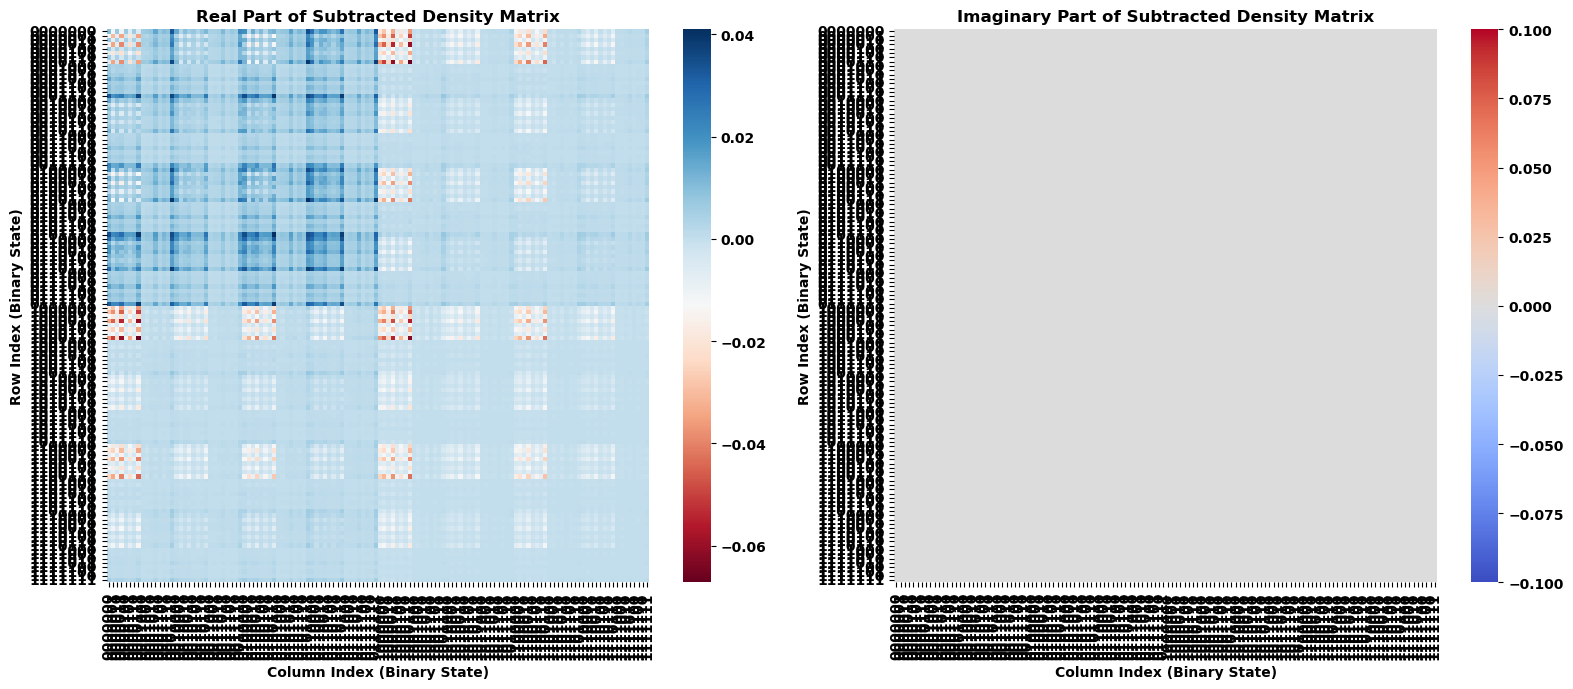

In [59]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Pair-wise Search ---")
print("="*40)

dens_thr = 0.01
#best_cnot_sequence, min_kl_sum, all_possible_single_cnots, working_pool = find_best_cnot_sequence_iterative_pairwise(
all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_pairwise2(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= dens_thr # 0.4 
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'1111': 229, '0101': 354, '0001': 647, '0110': 141, '0011': 966, '0111': 1367, '1110': 30, '1011': 182, '1001': 99, '0000': 532, '0010': 199, '1000': 71, '0100': 77, '1101': 52, '1010': 43, '1100': 11}
Counts for c_measure2: {'011': 976, '000': 1882, '010': 1343, '001': 720, '110': 33, '100': 24, '111': 9, '101': 13}


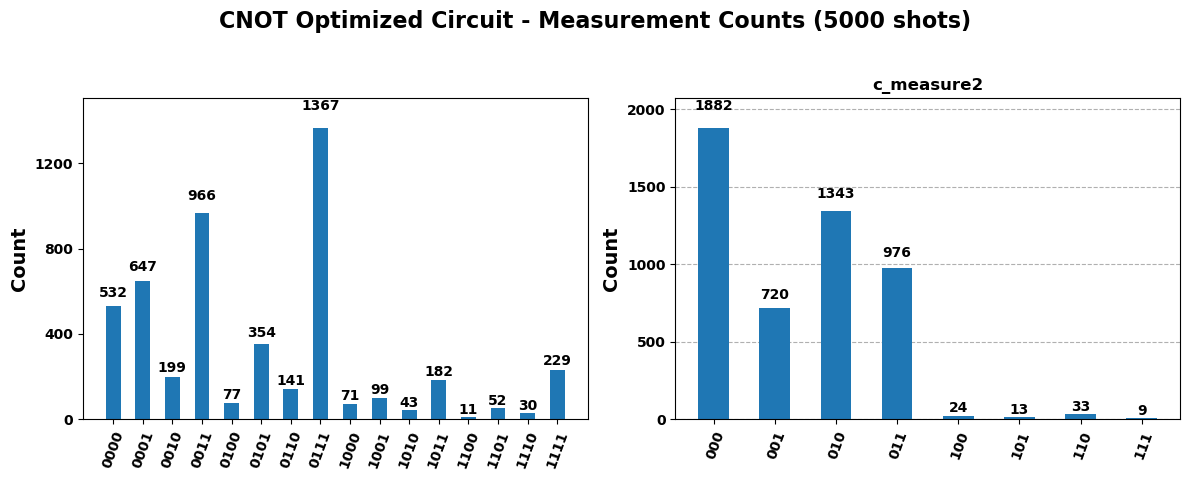

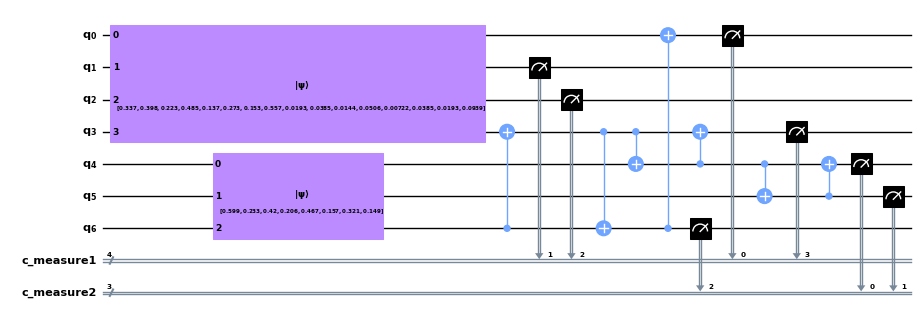

In [60]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

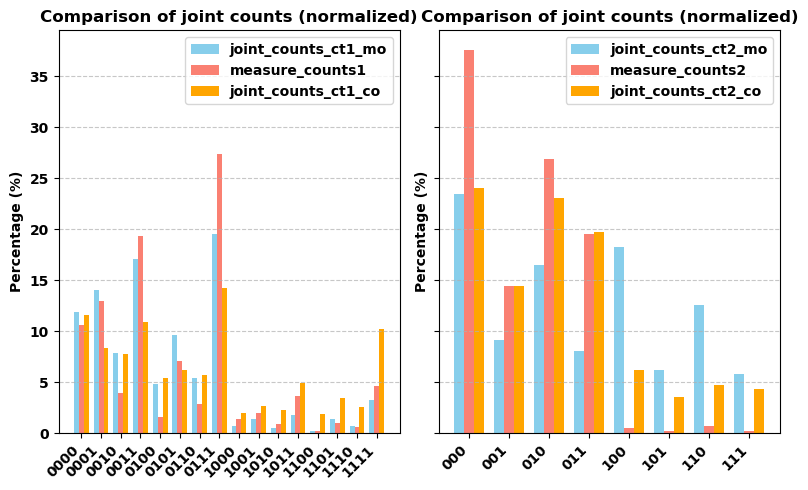

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')


In [69]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 20

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=dens_thr
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 24
Number of refined CNOT candidates: 42

--- Starting Epoch 1/42 (Addition) with CNOT: (4, 1) (KL: 0.846934) ---
    --> Found a better KL on this path: 0.779264 at depth 2
    --> Found a better KL on this path: 0.729942 at depth 3
    --> Found a better KL on this path: 0.699521 at depth 4
    --> Found a better KL on this path: 0.596182 at depth 5
    --> Found a better KL on this path: 0.566548 at depth 7
  Epoch 1 best KL Sum: 0.566548
  --> Epoch 1 found a new overall best KL Sum: 0.566548

--- Starting Epoch 2/42 (Addition) with CNOT: (2, 6) (KL: 1.165011) ---

--- Starting Epoch 3/42 (Addition) with CNOT: (4, 6) (KL: 1.003134) ---

--- Starting Epoch 4/42 (Addition) with CNOT: (5, 3) (KL: 0.808522) ---
    --> Found a better KL on this path: 0.684926 at depth 3
    --> Found a better KL on this path: 0.573917 at depth 5
    --> Found a better KL on this 


--- Simulating and Plotting Histograms for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0011': 1035, '0111': 1351, '0110': 162, '0001': 648, '1101': 109, '1011': 217, '1100': 83, '0000': 476, '0100': 99, '1001': 57, '0101': 321, '1111': 174, '0010': 199, '1010': 23, '1110': 38, '1000': 8}
Counts for c_measure2: {'011': 1098, '010': 1497, '000': 1350, '001': 977, '100': 10, '101': 22, '111': 32, '110': 14}


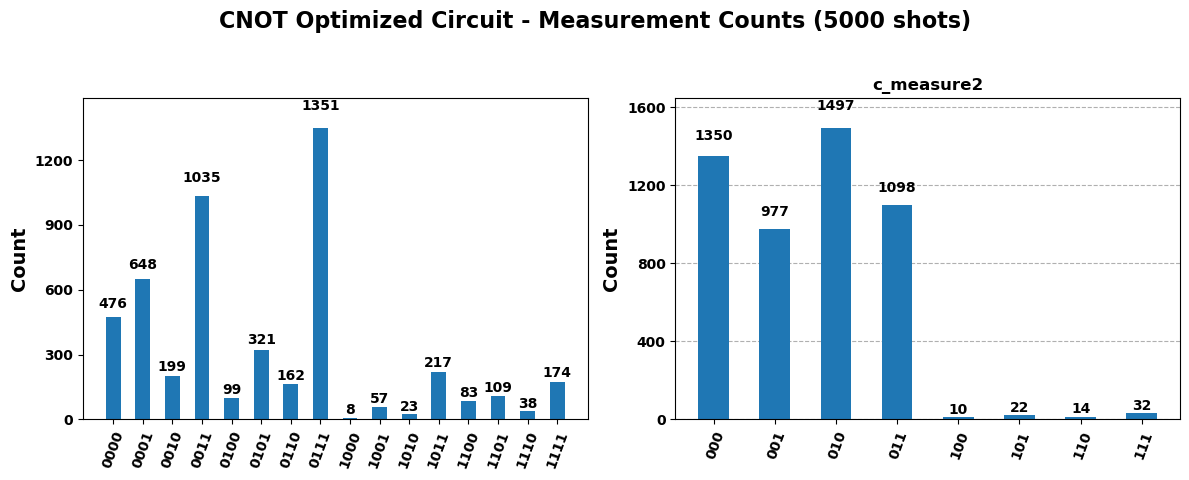

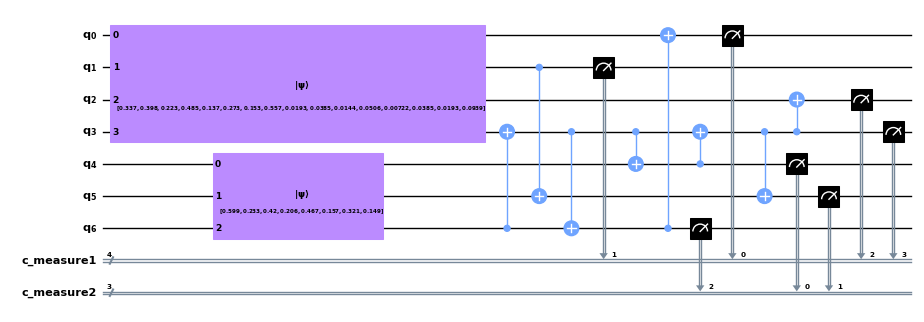

In [70]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

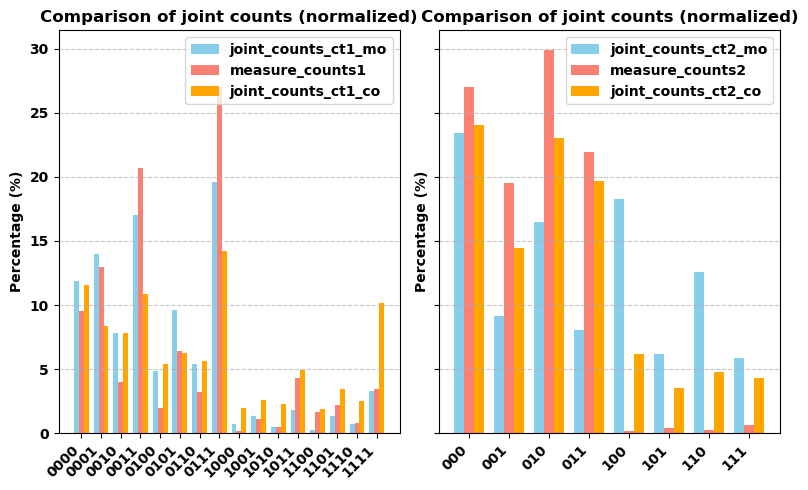

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (8 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.4684', '3.1396', '2.0036', '1.6253', '2.3191', '1.2382', '2.5881', '1.3948']
CRX Angle Optimization took: 18.63 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.4684', '3.1396', '2.0036', '1.6253', '2.3191', '1.2382', '2.5881', '1.3948']
  Minimum Combined KL Divergence with Optimized CRX: 0.119619


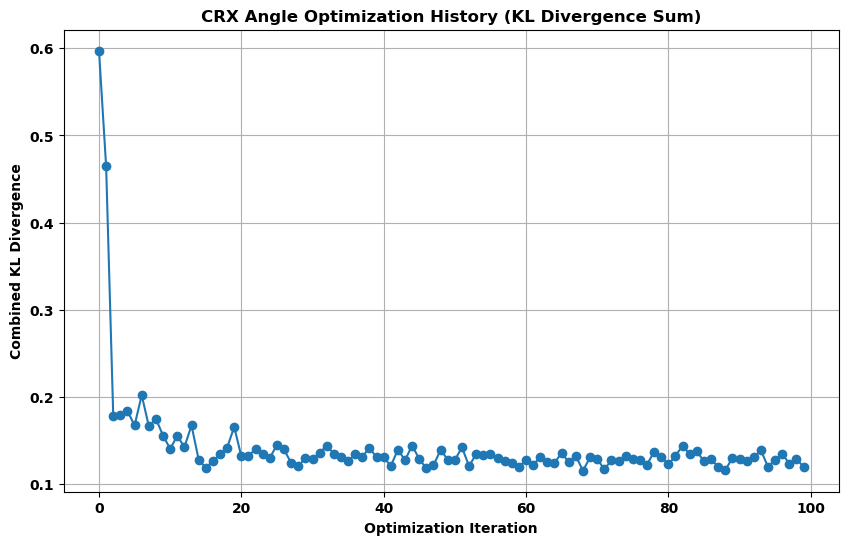


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                     ├»
«              │                                                                                                                                                      │»
«         q_1: ┤1                                                                                                                              

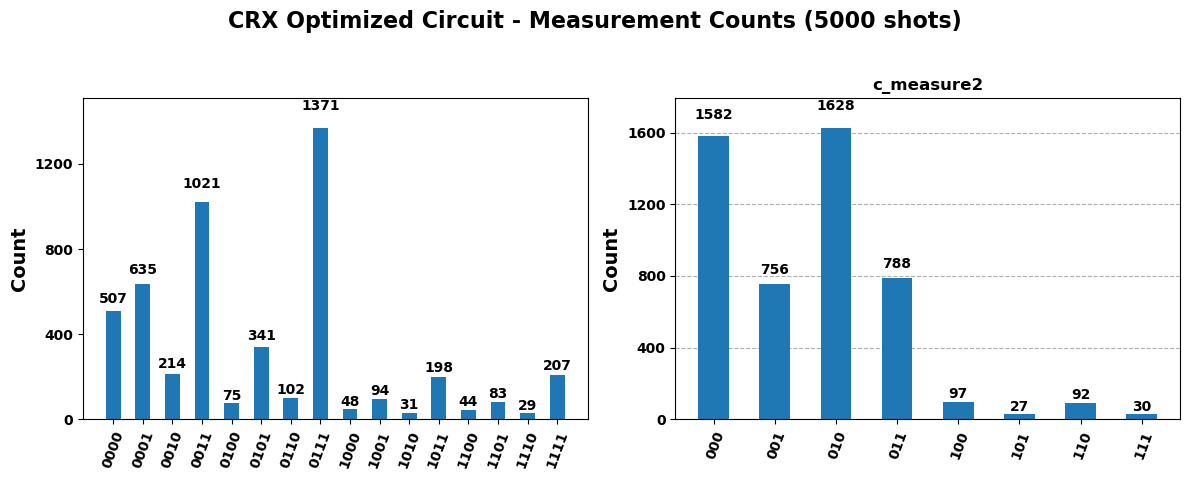

In [72]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")

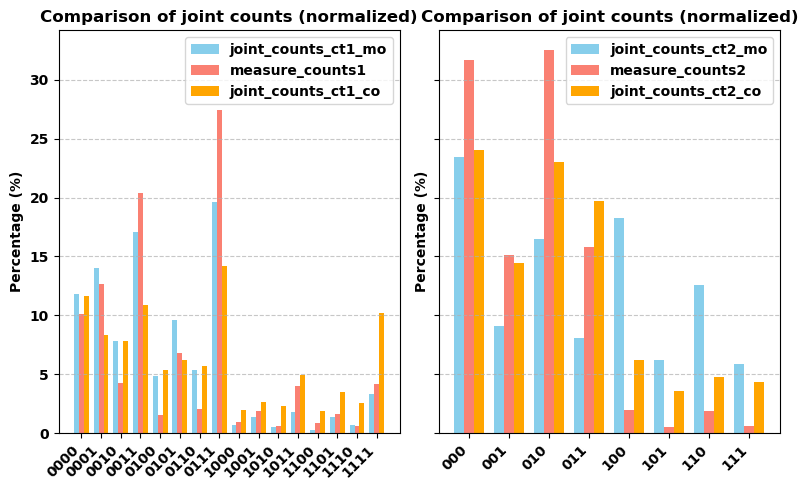

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts_anglkes.svg')


In [ ]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# Assuming all helper functions (_process_target_state_input, etc.) are defined.

def build_kl_divergence_matrix_for_qaoa(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05,
    include_single_cnot_kl: bool = True
):
    """
    Builds a matrix where M[i][j] represents the KL divergence of the circuit
    formed by cnot_i followed by cnot_j.
    
    This function first identifies potential CNOT candidates by analyzing
    the density matrix difference between the initial and target states,
    and then calculates the KL divergence for single CNOTs and all CNOT pairs.

    Args:
        circ1 (QuantumCircuit): The first base quantum circuit.
        circ2 (QuantumCircuit): The second base quantum circuit.
        state_probs_initial1 (dict): Initial state probabilities for circ1.
        state_probs_initial2 (dict): Initial state probabilities for circ2.
        state_vec_probs_target1 (dict): Target state probabilities for circ1's part.
        state_vec_probs_target2 (dict): Target state probabilities for circ2's part.
        nshots (int): Number of shots for circuit simulation.
        threshold (float): Threshold to identify significant off-diagonal elements.
        include_single_cnot_kl (bool): If True, the diagonal M[i][i] will store
                                       the KL divergence of the circuit with only cnot_i.

    Returns:
        np.ndarray: A square matrix where M[i][j] is the KL divergence for
                    the sequence [cnot_i, cnot_j].
        dict: A mapping from CNOT tuple to its index in the matrix.
        list: The list of initial CNOT candidates used.
        float: The initial KL divergence for the circuit with no CNOTs.
    """
    ng_circ1 = circ1.num_qubits
    
    print(f"\n--- Identifying Potential CNOT Linkers from Density Matrix Difference ---")

    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)
    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    initial_cnot_config = sorted(list(all_cnot_configurations))

    print(f"Number of potential CNOT candidates found: {len(initial_cnot_config)}")
    
    # --- Calculate Baseline KL Divergence (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_no_cnots = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs_baseline = score_circuit_kl_divergences(base_circuit_no_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs_baseline[0] + kl_divs_baseline[1] if kl_divs_baseline is not None else float('inf')
    print(f"Initial KL Divergence (no CNOTs): {initial_kl_sum:.6f}")

    # --- Start building the matrix with the identified candidates ---
    num_candidates = len(initial_cnot_config)
    kl_divergence_matrix = np.full((num_candidates, num_candidates), np.inf)
    cnot_to_index = {tuple(cnot): i for i, cnot in enumerate(initial_cnot_config)}

    print(f"\n--- Building KL Divergence Matrix ({num_candidates}x{num_candidates}) ---")

    if include_single_cnot_kl:
        print("Calculating KL for single CNOTs (diagonal elements)...")
        for i, cnot_i in enumerate(initial_cnot_config):
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, [cnot_i]
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[i, i] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i}]: {kl_divergence_matrix[i, i]:.6f}")

    print("Calculating KL for CNOT pairs (off-diagonal elements)...")
    n_pairs_tested = 0
    for cnot_i_val in initial_cnot_config:
        for cnot_j_val in initial_cnot_config:
            idx_i = cnot_to_index[tuple(cnot_i_val)]
            idx_j = cnot_to_index[tuple(cnot_j_val)]

            if idx_i == idx_j:
                continue

            n_pairs_tested += 1
            trial_sequence = [cnot_i_val, cnot_j_val]
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, trial_sequence
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[idx_i, idx_j] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i_val}, {cnot_j_val}]: {kl_divergence_matrix[idx_i, idx_j]:.6f}")
    
    print(f"Total CNOT pairs tested: {n_pairs_tested}")
    print("--- KL Divergence Matrix Built ---")

    return kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum

np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
    
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_for_qaoa(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.01, 
    include_single_cnot_kl=True
)

In [38]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp

def build_kl_qubo_paulis(kl_matrix: np.ndarray, initial_kl_sum: float) -> list[tuple[str, list[int], float]]:
    """
    Builds a Pauli list from a KL divergence matrix, with symmetrized
    quadratic interaction costs and a baseline subtraction.
    
    The costs are now calculated to represent the change in KL divergence
    relative to the initial KL divergence of the zero-CNOT circuit.

    Args:
        kl_matrix (np.ndarray): The matrix where kl_matrix[k, k] is the KL divergence
                                for a single CNOT k, and kl_matrix[k, l] is for the
                                sequence [CNOT k, CNOT l].
        initial_kl_sum (float): The baseline KL divergence with no CNOTs.

    Returns:
        list[tuple[str, list[int], float]]: The Pauli list in the format
                                             [('Pauli_string', [qubits], weight), ...].
    """
    num_qubits = kl_matrix.shape[0]
    pauli_list = []
    
    print("--- Deriving Pauli List from KL Divergence Matrix (with baseline subtraction) ---")

    INF_PENALTY = 1e9

    # Build the QUBO linear and quadratic coefficients based on relative costs
    qubo_linear = np.full(num_qubits, INF_PENALTY)
    qubo_quadratic = np.full((num_qubits, num_qubits), 0.0)

    for k in range(num_qubits):
        A_k_abs = kl_matrix[k, k]
        if not np.isinf(A_k_abs):
            # A_k is the improvement over the baseline
            qubo_linear[k] = A_k_abs - initial_kl_sum
        else:
            print(f"Warning: Single CNOT {k} has infinite KL. Assigning large penalty.")
            qubo_linear[k] = INF_PENALTY
            
    for k in range(num_qubits):
        for l in range(k + 1, num_qubits):
            kl_kl = kl_matrix[k, l]
            kl_lk = kl_matrix[l, k]

            if not np.isinf(kl_kl) and not np.isinf(kl_lk):
                symmetrized_kl_pair = (kl_kl + kl_lk) / 2
                
                # B_kl is the pure interaction cost, independent of the baseline
                B_kl = (symmetrized_kl_pair - initial_kl_sum) - (qubo_linear[k]) - (qubo_linear[l])
                qubo_quadratic[k, l] = B_kl
            else:
                print(f"Warning: CNOT pair ({k}, {l}) has an undefined KL in at least one order. Skipping ZZ term.")
                qubo_quadratic[k, l] = INF_PENALTY

    # Now, convert the QUBO coefficients to Pauli terms
    constant_offset = 0.0
    for k in range(num_qubits):
        zk_coeff = -qubo_linear[k] / 2.0
        for j in range(num_qubits):
            if k == j:
                continue
            zk_coeff -= qubo_quadratic[min(k,j), max(k,j)] / 4.0
        if zk_coeff != 0:
            pauli_list.append(("Z", [k], zk_coeff))
        constant_offset += qubo_linear[k] / 2.0
        
    for k in range(num_qubits):
        for l in range(k + 1, num_qubits):
            zz_coeff = qubo_quadratic[k, l] / 4.0
            if zz_coeff != 0:
                pauli_list.append(("ZZ", [k, l], zz_coeff))
            constant_offset += qubo_quadratic[k, l] / 4.0
            
    # The final constant should be zero, as all costs are relative to the baseline.
    # The energy of the 0-CNOT solution (all x_k=0) should be 0.
    # The total energy of a solution `s` is E(s) = H(s) + H(0).
    # Since we want E(s) to be the relative cost, the constant should be 0.

    print("--- Pauli List Created ---")
    return pauli_list

In [56]:
from qiskit.quantum_info import SparsePauliOp
n = kl_divergence_matrix.shape[0]
max_cut_paulis = build_kl_qubo_paulis(kl_divergence_matrix, initial_kl_sum)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

--- Deriving Pauli List from KL Divergence Matrix (with baseline subtraction) ---
--- Pauli List Created ---
Cost Function Hamiltonian: SparsePauliOp(['...'],
              coeffs=[ 8.62290919e-02+0.j, -1.29473663e-01+0.j, -3.39496770e-02+0.j,
 -1.76923594e-01+0.j,  1.18842586e-01+0.j,  2.61819830e-01+0.j,
  3.13233219e-01+0.j,  9.07837247e-02+0.j, -4.27009663e-01+0.j,
  2.12174117e-01+0.j,  3.92009403e-02+0.j, -1.42257488e-01+0.j,
  4.48609400e-01+0.j,  9.69444509e-02+0.j, -5.61770362e-01+0.j,
 -3.95401766e-02+0.j, -1.00669913e-01+0.j,  3.13365485e-01+0.j,
 -9.06670231e-01+0.j, -6.41180627e-01+0.j, -3.84375340e-01+0.j,
 -1.58688178e-01+0.j, -1.03423652e-01+0.j, -8.07737593e-03+0.j,
 -4.56160121e-01+0.j,  1.83118970e-01+0.j, -9.97000656e-02+0.j,
 -2.46617978e-01+0.j, -6.04813410e-02+0.j, -4.23571872e-01+0.j,
 -7.11800309e-02+0.j,  9.65616331e-03+0.j, -2.16912066e-01+0.j,
 -3.18793121e-01+0.j, -3.10469792e-01+0.j, -7.79040042e-02+0.j,
 -5.46323925e-01+0.j, -1.14666862e-02+0.j,  1.266539

In [ ]:
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import QiskitRuntimeService, Session

# Assuming cost_hamiltonian is defined
# Assuming nshots is defined

layers = 1
seed = 42
qaoa_circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=layers)
qaoa_circuit.measure_all()

# 5. Simulate the circuit
generic_backend = GenericBackendV2(n, seed=seed)

memory_in_mb = 8192
aer_simulator_backend = AerSimulator(max_memory_mb=memory_in_mb, method='statevector')
generic_backend._sim = aer_simulator_backend

pm = generate_preset_pass_manager(
    optimization_level=3, backend=generic_backend, seed_transpiler=seed
)

qaoa_circuit_transpiled = pm.run(qaoa_circuit)
#qaoa_circuit_transpiled.draw("mpl", fold=False, idle_wires=False)
init_params = np.zeros(2 * layers)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, Operator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler import Layout

from qiskit_ibm_runtime import (
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
    EstimatorOptions,
)
from qiskit_ibm_runtime.debug_tools import Neat
from qiskit_aer import AerSimulator

objective_func_vals = []


def cost_func_estimator(
    params: list, ansatz: QuantumCircuit, is_hamiltonian: SparsePauliOp, estimator: Estimator
) -> float:
    """Compute the cost function value using a parameterized ansatz and an estimator for a given Hamiltonian."""
    if is_hamiltonian.num_qubits != ansatz.num_qubits:
        is_hamiltonian = is_hamiltonian.apply_layout(ansatz.layout)
    pub = (ansatz, is_hamiltonian, params)
    job = estimator.run([pub])
    results = job.result()[0]
    cost = results.data.evs
    objective_func_vals.append(cost)
    return cost


def train_qaoa(
    params: list,
    circuit: QuantumCircuit,
    hamiltonian: SparsePauliOp,
    backend: QiskitRuntimeService.backend,
) -> tuple:
    """Optimize QAOA parameters using COBYLA and an estimator on a given backend."""
    with Session(backend=backend) as session:
        options = {"simulator": {"seed_simulator": seed}}
        estimator = Estimator(mode=session, options=options)
        estimator.options.default_shots = 100000

        result = minimize(
            cost_func_estimator,
            params,
            args=(circuit, hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": 200, "rhobeg": 1, "catol": 1e-3, "tol": 0.0001},
        )
    print(result)
    return result, objective_func_vals


result_qaoa, objective_func_vals = train_qaoa(
    init_params, qaoa_circuit_transpiled, cost_hamiltonian, generic_backend
)

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:
# Get the optimized parameters from the result
opt_params = result_qaoa.x
SHOTS = 10000

def sample_qaoa(opt_params, circuit, backend):

    # Submit the circuit to Sampler
    options = {"simulator": {"seed_simulator": seed}}
    sampler = Sampler(mode=backend, options=options)
    job = sampler.run([(circuit, opt_params)], shots=SHOTS)
    results_sampler = job.result()
    counts_list = results_sampler[0].data.meas.get_counts()
    display(plot_histogram(counts_list, title=f"Max cut with {backend.name}"))

    return counts_list

eigenvalues, eigenvectors = np.linalg.eig(cost_hamiltonian)
ground_energy = min(eigenvalues).real
num_solutions = eigenvalues.tolist().count(ground_energy)
index_solutions = np.where(eigenvalues == ground_energy)[0].tolist()
print(f"The ground energy of the Hamiltonian is {ground_energy}")
print(f"The number of solutions of the problem is {num_solutions}")
print(f"The list of the solutions based on their index is {index_solutions}")

In [75]:
import numpy as np
from scipy.optimize import root_scalar, minimize
import time
from dwave.samplers import SteepestDescentSolver
from dwave.system import LeapHybridSampler  # Import for the Leap Hybrid Sampler
import dimod  # Import for working with QUBOs

# Convert QUBO matrix to dictionary format
def qubo_matrix_to_dict(Q):
    qubo = {}
    for i in range(Q.shape[0]):
        for j in range(Q.shape[1]):
            if Q[i, j] != 0:
                qubo[(i, j)] = Q[i, j]
    return qubo

def quantum_test_refactored(Q_matrix, initial_cnot_config, mode='sa'):
    """
    Perform a quantum or simulated annealing test on a pre-built QUBO matrix.

    Parameters:
    - Q_matrix (numpy.ndarray): The QUBO matrix to solve.
    - initial_cnot_config (list): List of CNOT configurations corresponding to the Q_matrix.
    - mode (str): Solver mode ('sa' for simulated annealing, 'qa' for quantum annealing).

    Returns:
    - tuple: (selected_cnots_df, qa_sol)
        selected_cnots_df: DataFrame with selected CNOTs and their scores.
        qa_sol: Solution vector indicating selected CNOTs.
    """
    # Convert Q matrix to QUBO dictionary
    qubo = qubo_matrix_to_dict(Q_matrix)

    if mode == 'qa':
        # Quantum (Hybrid) Solver
        print("Quantum (Hybrid) Solver Results...")
        sampler = LeapHybridSampler()
        sampleset = sampler.sample_qubo(qubo)
        print("Hybrid Solver run time (seconds): ", sampleset.info.get('run_time') / 1_000_000)
    else:
        # Simulated Annealing Solver
        print("Simulated Annealing Solver Results...")
        sampler = dimod.SimulatedAnnealingSampler() # Using a more standard SA sampler
        sampleset = sampler.sample_qubo(qubo, num_reads=1000)

    # Retrieve and analyze results
    print("Energy: ", sampleset.first.energy)
    print("Occurrences: ", sampleset.first.num_occurrences)

    # Store selected CNOTs from the solution
    sample_dict = sampleset.first.sample
    values = list(sample_dict.values())
    qa_sol = np.array(values).astype(int)

    # Calculate the score for each CNOT
    cnot_scores = Q_matrix @ qa_sol

    # Create a DataFrame for analysis
    selected_cnots_df = pd.DataFrame(initial_cnot_config, columns=['control', 'target'])
    selected_cnots_df['selected'] = values
    selected_cnots_df['score'] = cnot_scores

    # Filter for selected CNOTs and sort
    selected_cnots_df = selected_cnots_df[(selected_cnots_df['selected'] > 0) & (selected_cnots_df['score'] < 0)]
    selected_cnots_df = selected_cnots_df.sort_values(by='score', ascending=True).reset_index(drop=True)

    return selected_cnots_df, qa_sol

In [61]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# Assuming all helper functions (_process_target_state_input, etc.) are defined.

def build_kl_divergence_matrix_for_qubo(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05,
    include_single_cnot_kl: bool = True
):
    """
    Builds a matrix where M[i][j] represents the KL divergence of the circuit
    formed by cnot_i followed by cnot_j.
    
    This function first identifies potential CNOT candidates by analyzing
    the density matrix difference between the initial and target states,
    and then calculates the KL divergence for single CNOTs and all CNOT pairs.

    Args:
        circ1 (QuantumCircuit): The first base quantum circuit.
        circ2 (QuantumCircuit): The second base quantum circuit.
        state_probs_initial1 (dict): Initial state probabilities for circ1.
        state_probs_initial2 (dict): Initial state probabilities for circ2.
        state_vec_probs_target1 (dict): Target state probabilities for circ1's part.
        state_vec_probs_target2 (dict): Target state probabilities for circ2's part.
        nshots (int): Number of shots for circuit simulation.
        threshold (float): Threshold to identify significant off-diagonal elements.
        include_single_cnot_kl (bool): If True, the diagonal M[i][i] will store
                                       the KL divergence of the circuit with only cnot_i.

    Returns:
        np.ndarray: A square matrix where M[i][j] is the KL divergence for
                    the sequence [cnot_i, cnot_j].
        dict: A mapping from CNOT tuple to its index in the matrix.
        list: The list of initial CNOT candidates used.
        float: The initial KL divergence for the circuit with no CNOTs.
    """
    ng_circ1 = circ1.num_qubits
    
    print(f"\n--- Identifying Potential CNOT Linkers from Density Matrix Difference ---")

    state_list1_initial, _ = _process_target_state_input(state_probs_initial1)
    state_list2_initial, _ = _process_target_state_input(state_probs_initial2)
    state_list1_target, _ = _process_target_state_input(state_vec_probs_target1)
    state_list2_target, _ = _process_target_state_input(state_vec_probs_target2)

    combined_state_amplitudes0 = np.kron(state_list2_initial, state_list1_initial)
    combined_state_amplitudes = np.kron(state_list2_target, state_list1_target)
    sv0 = Statevector(combined_state_amplitudes0)
    sv = Statevector(combined_state_amplitudes)
    dm0 = DensityMatrix(sv0)
    dm = DensityMatrix(sv)
    diff = dm - dm0
    matrix_data = diff.data

    row_indices, col_indices = np.where(matrix_data > threshold)
    row_indices0, col_indices0 = np.where(matrix_data < -threshold)

    dim = matrix_data.shape[0]
    labels = [bin(i)[2:].zfill(int(np.log2(dim))) for i in range(dim)]
    active_labels = set(labels[i] for i in row_indices) | set(labels[i] for i in col_indices)
    active_labels0 = set(labels[i] for i in row_indices0) | set(labels[i] for i in col_indices0)

    all_cnot_configurations = set()
    for ibit_string in active_labels0:
        for jbit_string in active_labels:
            i_locs = [len(ibit_string) - 1 - i for i, bit in enumerate(ibit_string) if bit == '1']
            j_locs = [len(jbit_string) - 1 - i for i, bit in enumerate(jbit_string) if bit == '1']
            all_cnot_configurations.update(create_cnot_pairs_from_locations(i_locs, j_locs))
    initial_cnot_config = sorted(list(all_cnot_configurations))

    print(f"Number of potential CNOT candidates found: {len(initial_cnot_config)}")
    
    # --- Calculate Baseline KL Divergence (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_no_cnots = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs_baseline = score_circuit_kl_divergences(base_circuit_no_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs_baseline[0] + kl_divs_baseline[1] if kl_divs_baseline is not None else float('inf')
    print(f"Initial KL Divergence (no CNOTs): {initial_kl_sum:.6f}")

    # --- Start building the matrix with the identified candidates ---
    num_candidates = len(initial_cnot_config)
    kl_divergence_matrix = np.full((num_candidates, num_candidates), np.inf)
    cnot_to_index = {tuple(cnot): i for i, cnot in enumerate(initial_cnot_config)}

    print(f"\n--- Building KL Divergence Matrix ({num_candidates}x{num_candidates}) ---")

    if include_single_cnot_kl:
        print("Calculating KL for single CNOTs (diagonal elements)...")
        for i, cnot_i in enumerate(initial_cnot_config):
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, [cnot_i]
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[i, i] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i}]: {kl_divergence_matrix[i, i]:.6f}")

    print("Calculating KL for CNOT pairs (off-diagonal elements)...")
    n_pairs_tested = 0
    for cnot_i_val in initial_cnot_config:
        for cnot_j_val in initial_cnot_config:
            idx_i = cnot_to_index[tuple(cnot_i_val)]
            idx_j = cnot_to_index[tuple(cnot_j_val)]

            if idx_i == idx_j:
                continue

            n_pairs_tested += 1
            trial_sequence = [cnot_i_val, cnot_j_val]
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, trial_sequence
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[idx_i, idx_j] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i_val}, {cnot_j_val}]: {kl_divergence_matrix[idx_i, idx_j]:.6f}")
    
    print(f"Total CNOT pairs tested: {n_pairs_tested}")
    print("--- KL Divergence Matrix Built ---")

    return kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum

np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
    
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_for_qubo(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.01, 
    include_single_cnot_kl=True
)


--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---
Number of potential CNOT candidates found: 42
Initial KL Divergence (no CNOTs): 0.852572

--- Building KL Divergence Matrix (42x42) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 1722
--- KL Divergence Matrix Built ---


In [72]:
import numpy as np
import numpy as np

def kl_to_qubo_matrix(kl_matrix: np.ndarray, initial_kl_sum: float) -> np.ndarray:
    """
    Builds a QUBO matrix from a KL divergence matrix.

    This function transforms a matrix of KL divergences into a Quadratic Unconstrained
    Binary Optimization (QUBO) matrix. The resulting matrix can be used by a
    QUBO solver to find the optimal selection of CNOT gates that minimizes
    the KL divergence of a quantum circuit.

    The QUBO problem is formulated to minimize a cost function where the energy
    of a solution (a set of selected CNOTs) corresponds to the circuit's
    relative KL divergence.

    Args:
        kl_matrix (np.ndarray): A square matrix where:
                                - kl_matrix[k, k] is the KL divergence of a circuit with a
                                  single CNOT gate `k`.
                                - kl_matrix[k, l] is the KL divergence of a circuit with
                                  the sequence of CNOT gates `k` then `l`.
        initial_kl_sum (float): The baseline KL divergence of the circuit with
                                no CNOT gates. This value is used to calculate
                                the cost relative to the zero-CNOT circuit.

    Returns:
        np.ndarray: The resulting QUBO matrix, Q. This is an upper triangular
                    matrix (with the diagonal included) containing the coefficients
                    for the QUBO objective function:
                    E(x) = sum(Q_ij * x_i * x_j) for i <= j.
                    
    Raises:
        ValueError: If kl_matrix is not a square matrix.
    """
    if kl_matrix.shape[0] != kl_matrix.shape[1]:
        raise ValueError("kl_matrix must be a square matrix.")

    num_vars = kl_matrix.shape[0]
    qubo_matrix = np.zeros((num_vars, num_vars))

    # A large penalty is assigned to invalid or infinite KL divergences to
    # discourage the solver from selecting those CNOT gates or pairs.
    INF_PENALTY = 1e9

    # --- Step 1: Calculate Linear Coefficients (Diagonal Terms, Q_ii) ---
    # These terms represent the cost of selecting a single CNOT gate.
    for i in range(num_vars):
        if not np.isinf(kl_matrix[i, i]):
            # The linear cost is the single-gate KL divergence relative to the baseline.
            cost_i = kl_matrix[i, i] - initial_kl_sum
            qubo_matrix[i, i] = cost_i
        else:
            # Assign a large penalty for an infinite KL divergence.
            qubo_matrix[i, i] = INF_PENALTY

    # --- Step 2: Calculate Quadratic Coefficients (Off-Diagonal Terms, Q_ij) ---
    # These terms represent the synergistic interaction cost of selecting a pair
    # of CNOT gates, isolated from their individual contributions.
    for i in range(num_vars):
        for j in range(i + 1, num_vars):
            kl_ij = kl_matrix[i, j]
            kl_ji = kl_matrix[j, i]

            if not np.isinf(kl_ij) and not np.isinf(kl_ji):
                # The total cost of the pair is the average of the two possible orderings.
                symmetrized_kl_pair = (kl_ij + kl_ji) / 2
                
                # Get the pre-computed linear costs from the diagonal of the QUBO matrix.
                cost_i = qubo_matrix[i, i]
                cost_j = qubo_matrix[j, j]
                
                # The interaction coefficient Q_ij is the total cost of the pair minus
                # the sum of their individual linear costs. This isolates the effect
                # of their combination.
                # E(x_i=1, x_j=1) = Q_ii*1 + Q_jj*1 + Q_ij*1*1
                # We want E to be the relative KL divergence of the pair:
                # E = symmetrized_kl_pair - initial_kl_sum
                # Therefore, Q_ij = (symmetrized_kl_pair - initial_kl_sum) - Q_ii - Q_jj
                interaction_cost = (symmetrized_kl_pair - initial_kl_sum) - cost_i - cost_j
                
                qubo_matrix[i, j] = interaction_cost
            else:
                # Assign a large penalty if the KL divergence for the pair is infinite.
                qubo_matrix[i, j] = INF_PENALTY

    return qubo_matrix

In [77]:
initial_cnot_config

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (1, 0),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 0),
 (2, 1),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 5),
 (4, 6),
 (5, 0),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 6),
 (6, 0),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5)]

In [73]:
# Assuming kl_divergence_matrix and initial_cnot_config are already built from your code
# We create a dummy Q_matrix here for demonstration
kl_divergence_matrix = kl_divergence_matrix # This is the matrix you generated
initial_cnot_config = initial_cnot_config # This is the list of CNOT candidates

kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)
print("Number of negative values in qubo matrix: ", str(np.sum(kl_div_mat_qubo<0)))

Number of negative values in qubo matrix:  408


In [76]:
# Solve using simulated annealing
print("--- Starting Simulated Annealing ---")
sa_selected_cnots, sa_solution_vector = quantum_test_refactored(
    kl_div_mat_qubo, 
    initial_cnot_config, 
    mode='sa'
)

print("\nSimulated Annealing Results:")
print(sa_selected_cnots)

--- Starting Simulated Annealing ---
Simulated Annealing Solver Results...
Energy:  -12.539748317349922
Occurrences:  1

Simulated Annealing Results:
    control  target  selected     score
0         1       0         1 -2.896447
1         0       1         1 -2.295183
2         2       0         1 -1.894414
3         0       6         1 -1.451151
4         2       1         1 -1.374331
5         0       4         1 -1.099695
6         1       6         1 -0.870012
7         1       2         1 -0.490016
8         4       6         1 -0.481714
9         0       2         1 -0.377579
10        2       5         1 -0.183236
11        4       1         1 -0.150281
12        6       0         1 -0.115109
13        3       0         1 -0.082352
14        0       5         1 -0.042787
15        3       4         1 -0.035688
16        5       4         1 -0.027916
17        3       1         1 -0.024115
